<a href="https://colab.research.google.com/github/ligafinancefiap-svg/core-finance-lib/blob/main/01_Data_Lake_Commodities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Segmento - Commodities - Ingestão e Incremento de dados da B3



In [5]:
import yfinance as yf
import pandas as pd
import os
from google.colab import drive
from datetime import datetime, timedelta

# 1. Configuração do Segmento
segmento = "commodities"
ativos = ['VALE3.SA', 'PETR4.SA', 'CSNA3.SA', 'SUZB3.SA', 'PRIO3.SA']
caminho_arquivo = f'/content/drive/MyDrive/DATA_LAKE/01_Bronze/b3_{segmento}_brutos.csv'

drive.mount('/content/drive')
print(f"🚀 Iniciando atualização do segmento: {segmento.upper()}")

# 2. Lógica de Incremento
if os.path.exists(caminho_arquivo):
    df_antigo = pd.read_csv(caminho_arquivo, index_col=0, parse_dates=True)
    ultima_data = df_antigo.index.max()
    data_inicio = ultima_data + timedelta(days=1)

    print(f"📊 Arquivo encontrado. Última atualização: {ultima_data.date()}")

    if data_inicio.date() >= datetime.now().date():
        print("✅ Os dados já estão atualizados até hoje!")
        df_final = df_antigo
    else:
        print(f"📥 Buscando novos dados a partir de: {data_inicio.date()}")
        df_novo = yf.download(ativos, start=data_inicio, auto_adjust=True)['Close']

        if not df_novo.empty:
            df_final = pd.concat([df_antigo, df_novo])
            print(f"✅ {len(df_novo)} novas linhas adicionadas.")
        else:
            print("⚠️ Nenhum dado novo encontrado.")
            df_final = df_antigo
else:
    print("📁 Arquivo não encontrado. Criando base histórica (5 anos)...")
    df_final = yf.download(ativos, period="5y", auto_adjust=True)['Close']
    print(f"✅ Base histórica criada com {len(df_final)} linhas.")

# 3. Salvando o resultado final
df_final.to_csv(caminho_arquivo)
print(f"💾 Arquivo 'b3_{segmento}_brutos.csv' salvo com sucesso no Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Iniciando atualização do segmento: COMMODITIES
📊 Arquivo encontrado. Última atualização: 2026-03-09
✅ Os dados já estão atualizados até hoje!
💾 Arquivo 'b3_commodities_brutos.csv' salvo com sucesso no Drive.


Segmento - Commodities - Biblioteca de Funções e Relatório

In [6]:
import numpy as np

def gerar_relatorio_commodities(caminho):
    df = pd.read_csv(caminho, index_col=0, parse_dates=True)

    # Preços atuais formatados em R$
    precos = df.iloc[-1].map("R$ {:.2f}".format)

    # Retorno total formatado em %
    retorno = ((df.iloc[-1] / df.iloc[0] - 1) * 100).map("{:.2f}%".format)

    # Volatilidade anualizada formatada em %
    vol = (df.pct_change().std() * np.sqrt(252) * 100).map("{:.2f}%".format)

    relatorio = pd.DataFrame({
        "Preço Atual": precos,
        "Retorno Total": retorno,
        "Risco (Vol)": vol
    }).sort_values(by="Retorno Total", ascending=False)

    return df, relatorio

df_comm, relatorio_executivo = gerar_relatorio_commodities(caminho_arquivo)
print(f"\n📊 RELATÓRIO EXECUTIVO - {segmento.upper()}")
print(relatorio_executivo)


📊 RELATÓRIO EXECUTIVO - COMMODITIES
         Preço Atual Retorno Total Risco (Vol)
PETR4.SA    R$ 43.92       608.38%      31.74%
VALE3.SA    R$ 77.68        30.35%      29.65%
PRIO3.SA    R$ 62.42       216.62%      40.35%
CSNA3.SA     R$ 7.07       -68.83%      46.07%
SUZB3.SA    R$ 54.42       -21.30%      28.19%


Segmento - Commodities - Dashboard de Visualização

/tmp/ipykernel_163/3507731385.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.annotate(txt, (risk[i], ret[i]), xytext=(5,5), textcoords='offset points', fontweight='bold')
/tmp/ipykernel_163/3507731385.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


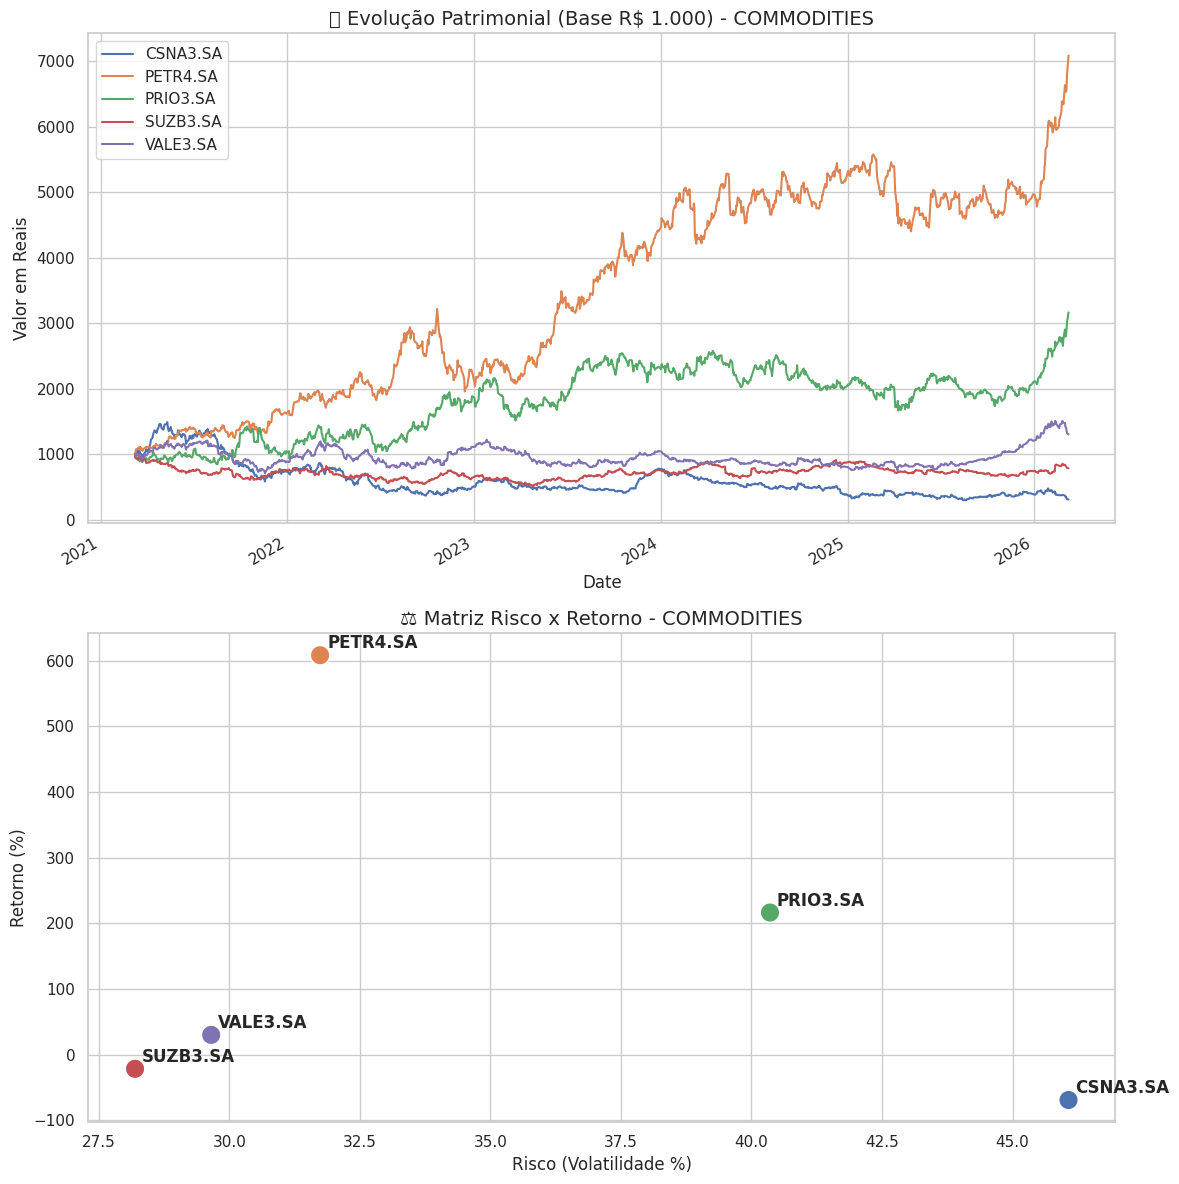

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_dashboard_commodities(df, nome_seg):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # Gráfico 1: Evolução Patrimonial
    (df / df.iloc[0] * 1000).plot(ax=ax1)
    ax1.set_title(f"📈 Evolução Patrimonial (Base R$ 1.000) - {nome_seg.upper()}", fontsize=14)
    ax1.set_ylabel("Valor em Reais")

    # Gráfico 2: Matriz Risco x Retorno
    ret = (df.iloc[-1] / df.iloc[0] - 1) * 100
    risk = df.pct_change().std() * np.sqrt(252) * 100
    sns.scatterplot(x=risk, y=ret, s=200, hue=ret.index, ax=ax2, legend=False)

    for i, txt in enumerate(ret.index):
        ax2.annotate(txt, (risk[i], ret[i]), xytext=(5,5), textcoords='offset points', fontweight='bold')

    ax2.set_title(f"⚖️ Matriz Risco x Retorno - {nome_seg.upper()}", fontsize=14)
    ax2.set_xlabel("Risco (Volatilidade %)")
    ax2.set_ylabel("Retorno (%)")

    plt.tight_layout()
    plt.show()

gerar_dashboard_commodities(df_comm, segmento)